# Pandas and Matplotlib Practice Questions

Use the sample values in the setup cell: products are Notebook, Pen, and Marker; categories are Paper and Writing; regions are North, South, East, and West. Quantities are 12, 30, 15, 8, 25, 18, 10, and 22; prices are 3.50, 1.20, 2.00, 3.50, 1.20, 2.00, 3.50, and 1.20. Answer the questions using these values. The notebook contains questions only; add your own code in new cells to solve them.

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = {
    "product": ["Notebook", "Pen", "Marker", "Notebook", "Pen", "Marker", "Notebook", "Pen"],
    "category": ["Paper", "Writing", "Writing", "Paper", "Writing", "Writing", "Paper", "Writing"],
    "region": ["North", "South", "East", "West", "North", "South", "East", "West"],
    "quantity": [12, 30, 15, 8, 25, 18, 10, 22],
    "price": [3.50, 1.20, 2.00, 3.50, 1.20, 2.00, 3.50, 1.20]
}

df = pd.DataFrame(data)
df

,product,category,region,quantity,price
0,Notebook,Paper,North,12,3.5
1,Pen,Writing,South,30,1.2
2,Marker,Writing,East,15,2.0
3,Notebook,Paper,West,8,3.5
4,Pen,Writing,North,25,1.2
5,Marker,Writing,South,18,2.0
6,Notebook,Paper,East,10,3.5
7,Pen,Writing,West,22,1.2


## Pandas Questions

1. The DataFrame contains 8 sales records. What are its number of rows and columns?
2. What are the column names and data types for `product`, `category`, `region`, `quantity`, and `price`?
3. For each record, what is the revenue when you multiply its `quantity` by its `price` (for example, the first Notebook record has quantity 12 and price 3.50)?
4. What is the total quantity sold for Pen, using its quantities 30, 25, and 22?
5. Which records have a quantity greater than 15? Include the product and region for each matching record.
6. Using the prices and quantities provided, what is the total revenue for Notebook, Pen, and Marker individually?
7. What are the total quantities and total revenues for the Paper and Writing categories?
8. What is the total revenue for North, South, East, and West, and which region has the highest total?

1. The DataFrame contains 8 sales records. What are its number of rows and columns?

In [83]:
df.shape

(8, 5)

2. What are the column names and data types for `product`, `category`, `region`, `quantity`, and `price`?

In [84]:
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   product   8 non-null      str    
 1   category  8 non-null      str    
 2   region    8 non-null      str    
 3   quantity  8 non-null      int64  
 4   price     8 non-null      float64
dtypes: float64(1), int64(1), str(3)
memory usage: 452.0 bytes


3. For each record, what is the revenue when you multiply its `quantity` by its `price` (for example, the first Notebook record has quantity 12 and price 3.50)?

In [85]:
df["revenue"]=df["quantity"]*df["price"]
df

,product,category,region,quantity,price,revenue
0,Notebook,Paper,North,12,3.5,42.0
1,Pen,Writing,South,30,1.2,36.0
2,Marker,Writing,East,15,2.0,30.0
3,Notebook,Paper,West,8,3.5,28.0
4,Pen,Writing,North,25,1.2,30.0
5,Marker,Writing,South,18,2.0,36.0
6,Notebook,Paper,East,10,3.5,35.0
7,Pen,Writing,West,22,1.2,26.4


4. What is the total quantity sold for Pen, using its quantities 30, 25, and 22?

In [86]:
quantity_pen=df[df["product"]=="Pen"]["quantity"].sum()
quantity_pen

np.int64(77)

5. Which records have a quantity greater than 15? Include the product and region for each matching record.

In [87]:
df_quantity15=df[df["quantity"]>15][["product","region"]]
df_quantity15


,product,region
1,Pen,South
4,Pen,North
5,Marker,South
7,Pen,West


6. Using the prices and quantities provided, what is the total revenue for Notebook, Pen, and Marker individually?

In [88]:
df
df1=df.groupby('product')["revenue"].sum().reset_index(name="revenue")
df1

,product,revenue
0,Marker,66.0
1,Notebook,105.0
2,Pen,92.4


7. What are the total quantities and total revenues for the Paper and Writing categories?

In [89]:
df2=df.groupby("product")[["revenue","quantity"]].sum().reset_index()
df2

,product,revenue,quantity
0,Marker,66.0,33
1,Notebook,105.0,30
2,Pen,92.4,77


## Matplotlib Plotting Questions

9. Using the provided quantity and price values, how would you create a bar plot of total revenue for Notebook, Pen, and Marker? Add a title and axis labels.
10. Using the Paper and Writing category values, how would you create a pie chart comparing the total quantities sold in the two categories? Add category labels.
11. Using the North, South, East, and West records, how would you create a bar plot comparing total revenue by region? Add a title and axis labels.
12. How would you create a scatter plot using the eight quantity values (12, 30, 15, 8, 25, 18, 10, 22) and the corresponding price values (3.50, 1.20, 2.00, 3.50, 1.20, 2.00, 3.50, 1.20)? Add a title and axis labels.

9. Using the provided quantity and price values, how would you create a bar plot of total revenue for Notebook, Pen, and Marker? Add a title and axis labels.

In [106]:
df2=df.groupby("product")[["revenue","quantity"]].sum().reset_index()
df2

,product,revenue,quantity
0,Marker,66.0,33
1,Notebook,105.0,30
2,Pen,92.4,77


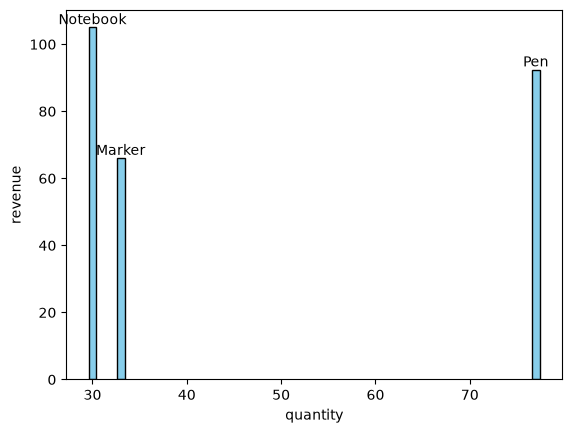

In [108]:
fig,ax=plt.subplots()
bars=ax.bar(df2["quantity"],
    df2["revenue"],
    color="skyblue",
    edgecolor="black")
ax.bar_label(bars,labels=df2["product"])
ax.set_xlabel("quantity")
ax.set_ylabel("revenue")
plt.show()


10. Using the Paper and Writing category values, how would you create a pie chart comparing the total quantities sold in the two categories? Add category labels.

11. Using the North, South, East, and West records, how would you create a bar plot comparing total revenue by region? Add a title and axis labels.

In [93]:
df_reg=df.groupby("region")["revenue"].sum().reset_index()
df_reg

,region,revenue
0,East,65.0
1,North,72.0
2,South,72.0
3,West,54.4


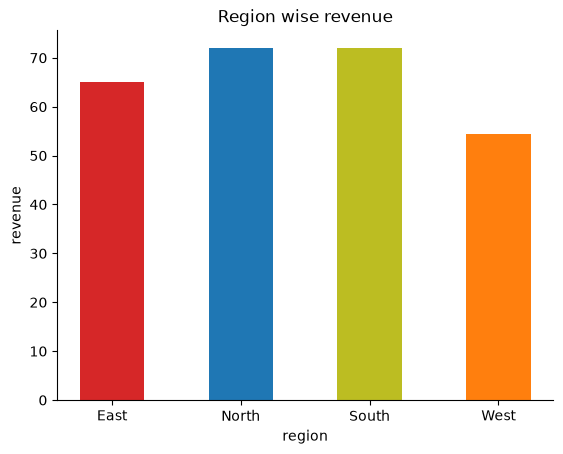

In [126]:
fig,ax=plt.subplots()
ax.spines[["top","right"]].set_visible(False)
bar_labels=df_reg.region
bar_colors=['tab:red','tab:blue','tab:olive','tab:orange']

ax.bar(df_reg.region,
       df_reg.revenue,
       label=bar_labels,
       color=bar_colors,
       width=0.5)
ax.set_xlabel("region")
ax.set_ylabel("revenue")
ax.set_title("Region wise revenue")


plt.show()


In [122]:
# plt.bar(df.region,df.revenue,
#         color="#6919d1",
#         edgecolor="#0fd629")
# plt.gca().spines["top"].set_visible(False)
# plt.gca().spines["right"].set_visible(False)
# plt.xlabel("region")
# plt.ylabel("revenue")
# plt.show()

12. How would you create a scatter plot using the eight quantity values (12, 30, 15, 8, 25, 18, 10, 22) and the corresponding price values (3.50, 1.20, 2.00, 3.50, 1.20, 2.00, 3.50, 1.20)? Add a title and axis labels.

In [ ]:
random_colors=np.random.rand(8)
random_colors
size=(np.random.rand(8))*500
size

array([100.47028637, 172.53927307, 225.64213081, 307.86404456,
        38.57482595, 398.1208104 , 152.89859639, 243.17080007])

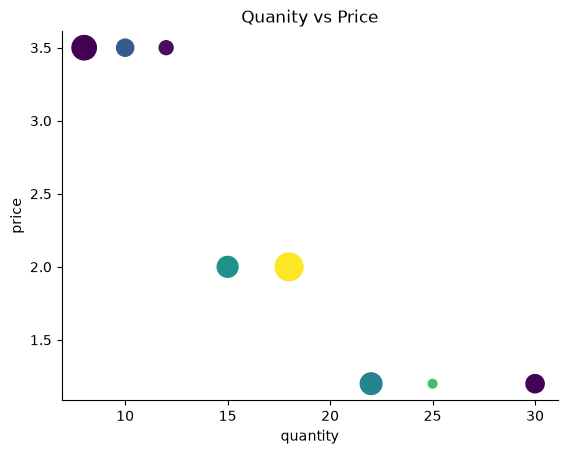

In [ ]:
plt.scatter(df.quantity,
            df.price,
            c=random_colors,
            cmap='viridis',
            s=size)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlabel("quantity")
plt.ylabel("price")
plt.title("Quanity vs Price")
plt.show()
